In [1]:
"""
2D One-Component Plasma (OCP) — Metropolis MC data generator for EwaldNN.

Physical setup
--------------
N unit charges (e = k_B = 1) in a square box of side L with periodic
boundary conditions and a uniform neutralizing background.
Number density fixed at n = 1 (L = sqrt(N)), giving Wigner-Seitz radius
    a = 1 / sqrt(pi * n) = 1 / sqrt(pi).
The single control parameter is
    Gamma = e^2 / (k_B T a) = sqrt(pi) / T.
Crystallization (liquid -> triangular Wigner crystal) occurs at Gamma ~ 130.

Ewald summation (2D, square box, neutralizing background)
----------------------------------------------------------
    E = E_real + E_recip + E_self + E_bg

    E_real  = (1/2) sum_{i!=j} erfc(alpha * r_ij) / r_ij   [minimum image]
    E_recip = (pi/A) sum_{G!=0} [erfc(G/2a)/G] |S(G)|^2
    E_self  = -N * alpha / sqrt(pi)
    E_bg    = -pi N^2 / (2 alpha^2 A)                       [neutralizing background]

    Ewald parameter: alpha = 6 / L  (balances real/recip truncation errors)
    Real-space cutoff: L/2 (minimum image); erfc(alpha*L/2) = erfc(3) ~ 2e-5
    Reciprocal cutoff: n_recip = 8 gives G_max / (2*alpha) ~ 3, same accuracy.
"""

import numpy as np
from scipy.special import erfc


# ── Reciprocal lattice ──────────────────────────────────────────────────────

def build_kvecs(L, n_recip=8):
    """
    All nonzero reciprocal-lattice vectors G = (2pi/L)(mx, my)
    with |mx|, |my| <= n_recip.  Returns (nG, 2) array.
    """
    idx = np.arange(-n_recip, n_recip + 1)
    mx, my = np.meshgrid(idx, idx, indexing='ij')
    mx, my = mx.ravel(), my.ravel()
    mask = ~((mx == 0) & (my == 0))
    return (2 * np.pi / L) * np.stack([mx[mask], my[mask]], axis=1).astype(float)


# ── Energy routines ─────────────────────────────────────────────────────────

def _real_energy(pos, L, alpha):
    """Vectorised real-space sum with minimum image convention."""
    diff = pos[:, None, :] - pos[None, :, :]        # (N, N, 2)
    diff -= L * np.round(diff / L)                   # minimum image
    r = np.sqrt((diff ** 2).sum(-1))                 # (N, N)
    np.fill_diagonal(r, np.inf)
    return 0.5 * np.sum(erfc(alpha * r) / r)


def _particle_real(i, pos_i, pos, L, alpha):
    """
    Real-space contribution of ONE particle (at pos_i) interacting with all
    others.  Returns the FULL sum (factor of 1/2 handled in delta_E).
    """
    diff = pos_i - pos                                # (N, 2)
    diff -= L * np.round(diff / L)
    r = np.sqrt((diff ** 2).sum(-1))
    r[i] = np.inf                                     # exclude self
    return np.sum(erfc(alpha * r) / r)


def structure_factors(pos, kvecs):
    """S(G) = sum_j exp(i G.r_j)  for all G.  Returns complex (nG,) array."""
    return np.sum(np.exp(1j * (kvecs @ pos.T)), axis=1)


def ewald_energy(pos, L, alpha, kvecs, recip_w, S=None):
    """
    Full 2D Ewald energy.  Pass precomputed S to skip re-summation.
    recip_w[k] = erfc(|G_k| / 2alpha) / |G_k|
    """
    N = len(pos)
    A = L ** 2
    if S is None:
        S = structure_factors(pos, kvecs)
    E_real  = _real_energy(pos, L, alpha)
    E_recip = (np.pi / A) * np.sum(recip_w * np.abs(S) ** 2)
    E_self  = -N * alpha / np.sqrt(np.pi)
    E_bg    = -np.pi * N ** 2 / (2 * alpha ** 2 * A)
    return E_real + E_recip + E_self + E_bg


# ── Monte Carlo ─────────────────────────────────────────────────────────────

class OCP2D:
    """
    Metropolis MC for the 2D one-component plasma.

    Convention: e = k_B = 1, density n = 1  =>  L = sqrt(N),  a = 1/sqrt(pi).
    Temperature from Gamma:  k_B T = 1 / (Gamma * a) = sqrt(pi) / Gamma.
    """

    def __init__(self, N, Gamma, n_recip=8, seed=None):
        if seed is not None:
            np.random.seed(seed)

        self.N     = N
        self.Gamma = Gamma
        self.L     = float(np.sqrt(N))           # unit density
        self.A     = self.L ** 2
        self.a     = 1.0 / np.sqrt(np.pi)        # Wigner-Seitz radius (n=1)
        self.kBT   = np.sqrt(np.pi) / Gamma      # k_B T  (e=k_B=1)
        self.beta  = 1.0 / self.kBT

        # Ewald parameter: alpha = 6/L gives erfc(alpha*L/2)=erfc(3)~2e-5
        self.alpha  = 6.0 / self.L

        self.kvecs   = build_kvecs(self.L, n_recip)
        self.kmods   = np.linalg.norm(self.kvecs, axis=1)
        self.recip_w = erfc(self.kmods / (2 * self.alpha)) / self.kmods

        # Initialise on triangular lattice (fast equilibration at large Gamma)
        self.pos    = self._triangular_lattice()
        self.S      = structure_factors(self.pos, self.kvecs)
        self.energy = ewald_energy(self.pos, self.L, self.alpha,
                                   self.kvecs, self.recip_w, self.S)

        self.step_size = 0.1 * self.a
        self._n_acc = self._n_att = 0

    # ── initialisation ───────────────────────────────────────────────────────

    def _triangular_lattice(self):
        n  = int(np.ceil(np.sqrt(self.N)))
        a1 = np.array([self.L / n, 0.0])
        a2 = np.array([self.L / (2 * n), self.L * np.sqrt(3) / (2 * n)])
        pts = [(i * a1 + j * a2) % self.L
               for i in range(n) for j in range(n)][:self.N]
        pos = np.array(pts) + 1e-2 * self.a * np.random.randn(self.N, 2)
        return pos % self.L

    # ── single-step energy update ────────────────────────────────────────────

    def _delta_E(self, i, pos_new):
        """
        Energy change when particle i moves to pos_new.
        Exploits precomputed S(G) to avoid O(N) reciprocal recomputation.
        Returns (dE, dS) where dS is the update to S.
        """
        # Real space
        E_r_old = _particle_real(i, self.pos[i], self.pos, self.L, self.alpha)
        E_r_new = _particle_real(i, pos_new,      self.pos, self.L, self.alpha)

        # Reciprocal space via S update
        ph_old = self.kvecs @ self.pos[i]          # (nG,)
        ph_new = self.kvecs @ pos_new               # (nG,)
        dS     = np.exp(1j * ph_new) - np.exp(1j * ph_old)
        S_new  = self.S + dS
        dE_rec = (np.pi / self.A) * np.sum(
            self.recip_w * (np.abs(S_new) ** 2 - np.abs(self.S) ** 2))

        return (E_r_new - E_r_old) + dE_rec, dS

    # ── Metropolis sweep ─────────────────────────────────────────────────────

    def sweep(self):
        """N single-particle Metropolis trials (one sweep)."""
        for _ in range(self.N):
            i        = np.random.randint(self.N)
            disp     = self.step_size * (2.0 * np.random.rand(2) - 1.0)
            pos_new  = (self.pos[i] + disp) % self.L

            dE, dS   = self._delta_E(i, pos_new)
            self._n_att += 1

            if dE <= 0.0 or np.random.rand() < np.exp(-self.beta * dE):
                self.pos[i]  = pos_new
                self.S      += dS
                self.energy += dE
                self._n_acc += 1

    def _tune_step(self):
        if self._n_att == 0:
            return
        rate = self._n_acc / self._n_att
        fac  = 1.1 if rate > 0.50 else 0.9
        if rate < 0.30 or rate > 0.55:
            self.step_size = float(np.clip(
                self.step_size * fac, 1e-4 * self.a, 0.4 * self.L))
        self._n_acc = self._n_att = 0

    # ── run ──────────────────────────────────────────────────────────────────

    def run(self, n_equil, n_prod, save_every=10, verbose=True):
        """
        Equilibrate then collect {pos, E} pairs.

        Returns
        -------
        configs  : (n_samples, N, 2)  particle positions
        energies : (n_samples,)       total Ewald energies
        """
        if verbose:
            print(f"  Gamma={self.Gamma:.0f}  N={self.N}  L={self.L:.2f}"
                  f"  alpha={self.alpha:.3f}  kBT={self.kBT:.4f}")

        for s in range(n_equil):
            self.sweep()
            if s % 200 == 0:
                self._tune_step()

        configs, energies = [], []
        for s in range(n_prod):
            self.sweep()
            if s % save_every == 0:
                configs.append(self.pos.copy())
                energies.append(self.energy)
            if s % 200 == 0:
                self._tune_step()

        configs  = np.array(configs)
        energies = np.array(energies)
        if verbose:
            print(f"  Mean E/N = {energies.mean()/self.N:.4f}")
            print(f"  Acceptance = {self._n_acc/max(self._n_att,1):.2f}"
                  f"  step = {self.step_size:.4f}")
        return configs, energies


# ── Density grid ─────────────────────────────────────────────────────────────

def to_density_grid(configs, L, grid_size=32):
    """
    Bin particle positions onto a 2D grid.

    Parameters
    ----------
    configs   : (n_samples, N, 2)
    L         : box side length
    grid_size : int

    Returns
    -------
    grids : (n_samples, grid_size, grid_size)  float
    """
    n_samples, N, _ = configs.shape
    grids = np.zeros((n_samples, grid_size, grid_size), dtype=np.float32)
    for s, cfg in enumerate(configs):
        ix = (cfg[:, 0] / L * grid_size).astype(int) % grid_size
        iy = (cfg[:, 1] / L * grid_size).astype(int) % grid_size
        np.add.at(grids[s], (ix, iy), 1.0)
    return grids


# ── Dataset generation ───────────────────────────────────────────────────────

def generate_dataset(gamma_list, N=200, n_equil=500, n_prod=1000,
                     save_every=10, grid_size=32, seed=0):
    """
    Generate {density_grid, energy} training pairs across Gamma values.
    Gamma is NOT passed to EwaldNN — it labels the sampling distribution only.

    Returns
    -------
    rho    : (n_total, grid_size, grid_size)  float32 density grids
    E      : (n_total,)                       float64 Ewald energies
    Gammas : (n_total,)                       float64 Gamma labels
    """
    all_rho, all_E, all_G = [], [], []

    for k, Gamma in enumerate(gamma_list):
        print(f"\n[{k+1}/{len(gamma_list)}] ", end="")
        sim = OCP2D(N=N, Gamma=Gamma, seed=seed + k)
        configs, energies = sim.run(n_equil, n_prod, save_every)

        all_rho.append(to_density_grid(configs, sim.L, grid_size))
        all_E.append(energies)
        all_G.append(np.full(len(energies), Gamma))

    rho    = np.concatenate(all_rho)
    E      = np.concatenate(all_E)
    Gammas = np.concatenate(all_G)
    print(f"\nDataset: {len(E)} samples, Gamma in {gamma_list}")
    return rho, E, Gammas


# ── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Spans liquid (10, 50), near transition (100, 140), crystal (200)
    GAMMA_LIST  = [10, 50, 100, 130, 140, 200]
    N           = 100     # particles  (use 200 for production runs)
    N_EQUIL     = 500     # equilibration sweeps
    N_PROD      = 1000    # production sweeps
    SAVE_EVERY  = 10      # snapshot interval (sweeps)
    GRID_SIZE   = 32      # density grid resolution

    rho, E, Gammas = generate_dataset(
        GAMMA_LIST, N=N, n_equil=N_EQUIL, n_prod=N_PROD,
        save_every=SAVE_EVERY, grid_size=GRID_SIZE
    )

    np.save("wigner_rho.npy",    rho)
    np.save("wigner_E.npy",      E)
    np.save("wigner_Gamma.npy",  Gammas)
    print("Saved: wigner_rho.npy  wigner_E.npy  wigner_Gamma.npy")
    print(f"Shapes: rho={rho.shape}  E={E.shape}  Gamma={Gammas.shape}")


[1/6]   Gamma=10  N=100  L=10.00  alpha=0.600  kBT=0.1772
  Mean E/N = -3.2358
  Acceptance = 0.81  step = 0.1209

[2/6]   Gamma=50  N=100  L=10.00  alpha=0.600  kBT=0.0354
  Mean E/N = -3.3296
  Acceptance = 0.62  step = 0.1209

[3/6]   Gamma=100  N=100  L=10.00  alpha=0.600  kBT=0.0177
  Mean E/N = -3.3463
  Acceptance = 0.52  step = 0.1099

[4/6]   Gamma=130  N=100  L=10.00  alpha=0.600  kBT=0.0136
  Mean E/N = -3.3527
  Acceptance = 0.54  step = 0.0909

[5/6]   Gamma=140  N=100  L=10.00  alpha=0.600  kBT=0.0127
  Mean E/N = -3.3524
  Acceptance = 0.53  step = 0.0909

[6/6]   Gamma=200  N=100  L=10.00  alpha=0.600  kBT=0.0089
  Mean E/N = -3.3576
  Acceptance = 0.52  step = 0.0751

Dataset: 600 samples, Gamma in [10, 50, 100, 130, 140, 200]
Saved: wigner_rho.npy  wigner_E.npy  wigner_Gamma.npy
Shapes: rho=(600, 32, 32)  E=(600,)  Gamma=(600,)


In [2]:
"""
Visualisation of 2D OCP Monte Carlo data for EwaldNN.

Requires wigner_rho.npy, wigner_E.npy, wigner_Gamma.npy
produced by the data generation script.

Four panels per Gamma value:
  A  Particle density grid  rho_ij
  B  Structure factor  S(q) = |FFT(rho)|^2
  C  Radial pair correlation  g(r)  estimated from the density grid
  D  Energy trace over production run

Plus one summary panel:
  E  Mean E/N vs Gamma
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d

# ── load data ────────────────────────────────────────────────────────────────

rho    = np.load("wigner_rho.npy")     # (n_total, G, G)
E      = np.load("wigner_E.npy")       # (n_total,)
Gammas = np.load("wigner_Gamma.npy")   # (n_total,)

gamma_list = sorted(set(Gammas.astype(int).tolist()))
G          = rho.shape[1]              # grid size

print(f"Loaded {len(E)} samples, grid {G}x{G}, Gamma in {gamma_list}")


# ── helpers ──────────────────────────────────────────────────────────────────

def structure_factor_2d(rho_grid):
    """
    S(q) = |FFT(rho)|^2 / N.
    Returns the shifted 2D power spectrum (zero frequency at centre).
    """
    ft = np.fft.fftshift(np.fft.fft2(rho_grid))
    N  = rho_grid.sum()
    return np.abs(ft) ** 2 / max(N, 1)


def radial_average(img):
    """
    Azimuthal average of a 2D image centred at img centre.
    Returns (r_pixels, profile).
    """
    cy, cx = np.array(img.shape) // 2
    y, x   = np.indices(img.shape)
    r      = np.sqrt((x - cx) ** 2 + (y - cy) ** 2).astype(int)
    r_max  = min(cx, cy)
    profile = np.array([img[r == ri].mean() if (r == ri).any() else 0.0
                         for ri in range(r_max)])
    return np.arange(r_max), profile


def pick_sample(gamma_val, which='mid'):
    """Return one representative density grid and its energy."""
    mask = (Gammas == gamma_val)
    idx  = np.where(mask)[0]
    if which == 'mid':
        i = idx[len(idx) // 2]
    elif which == 'last':
        i = idx[-1]
    else:
        i = idx[0]
    return rho[i], E[i]

Loaded 600 samples, grid 32x32, Gamma in [10, 50, 100, 130, 140, 200]


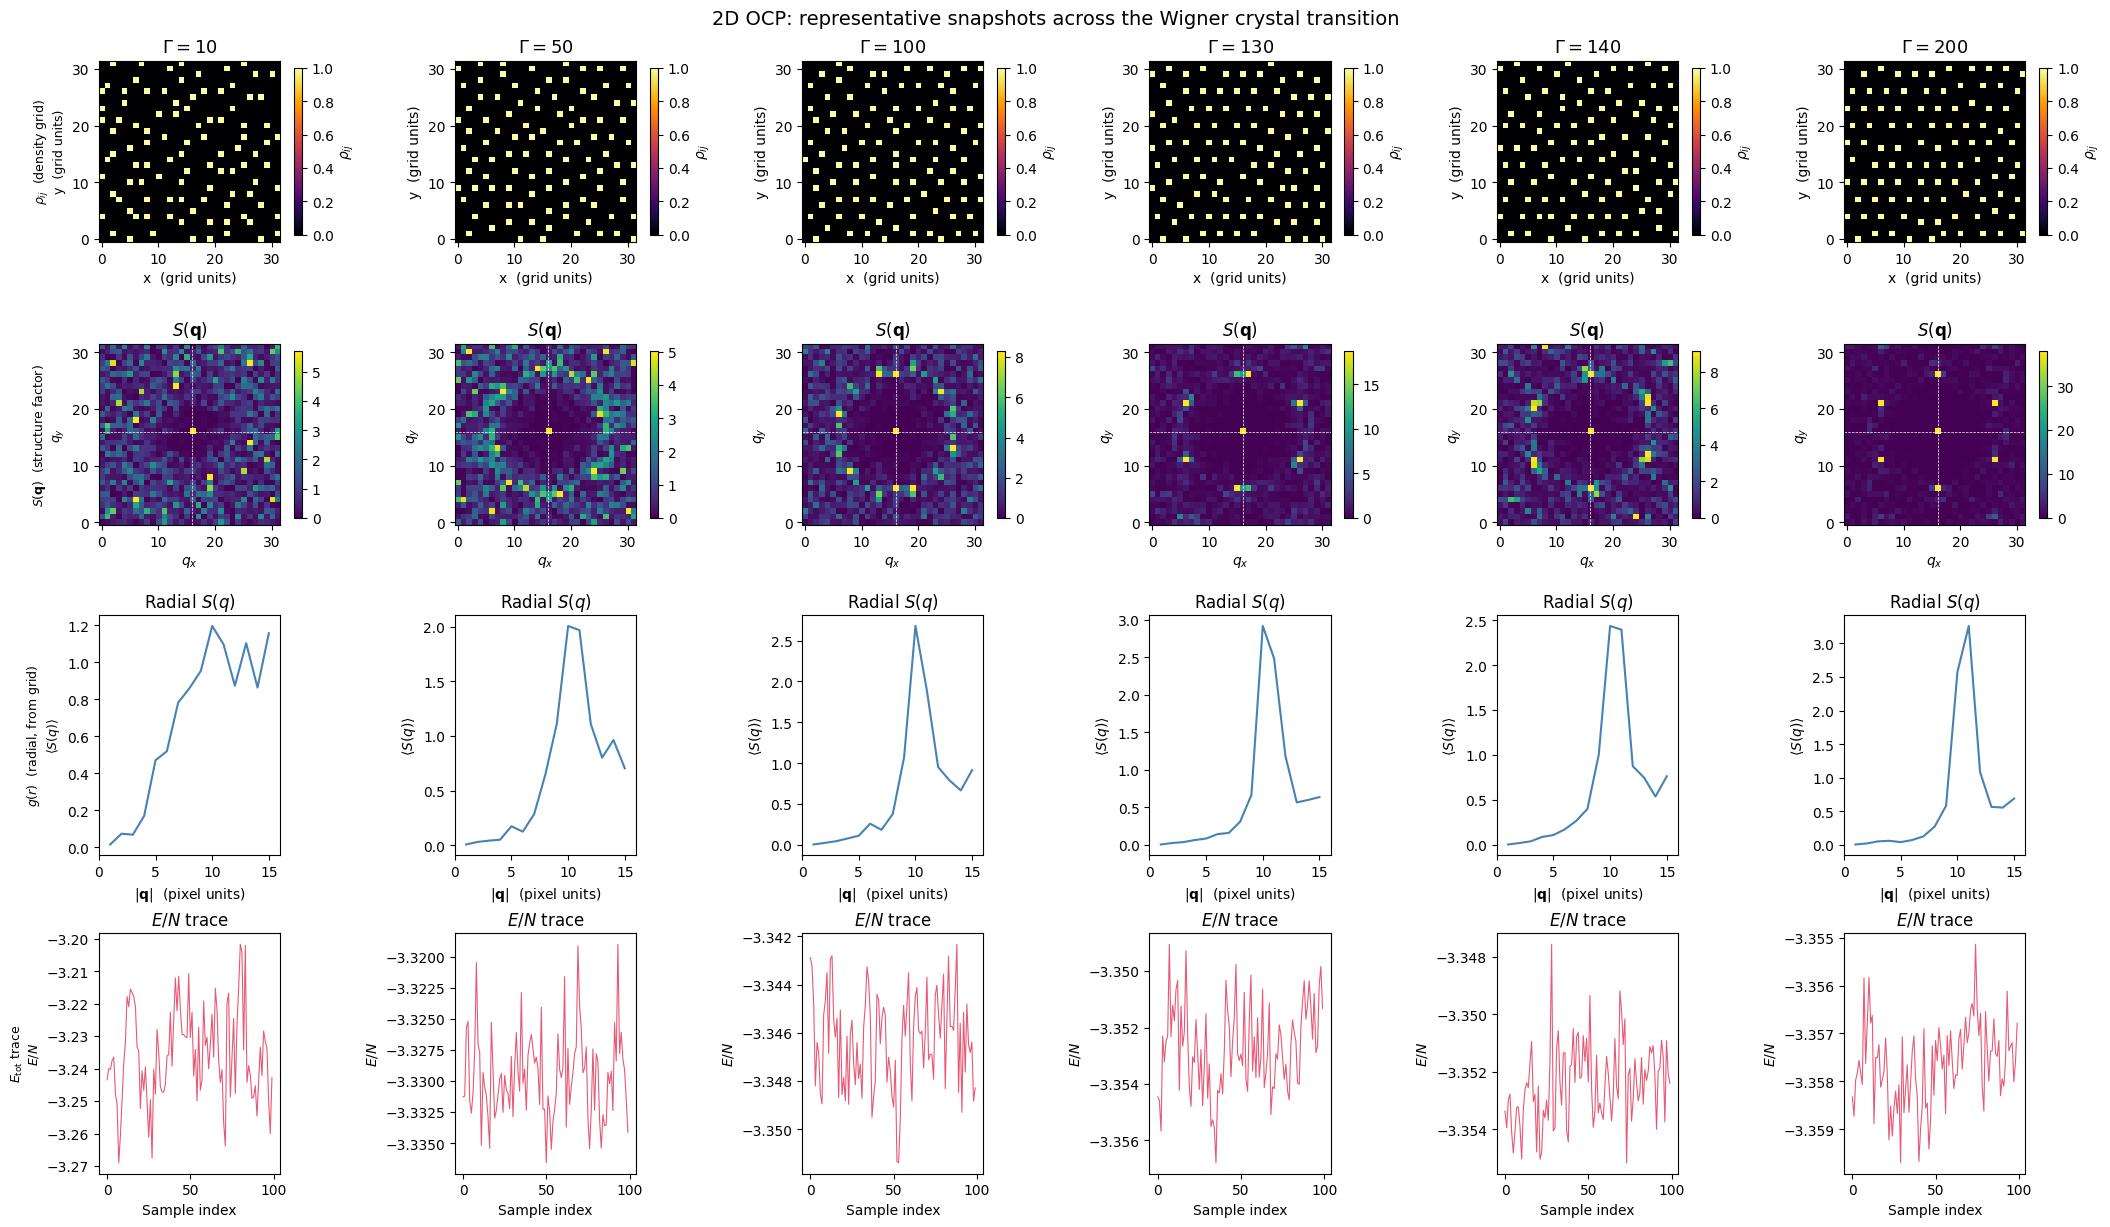

In [3]:
# ── Figure 1: per-Gamma panels ───────────────────────────────────────────────

n_gamma = len(gamma_list)
fig1, axes = plt.subplots(4, n_gamma,
                           figsize=(3.5 * n_gamma, 12),
                           constrained_layout=True)

if n_gamma == 1:               # ensure 2D indexing works
    axes = axes[:, np.newaxis]

row_labels = [r"$\rho_{ij}$  (density grid)",
              r"$S(\mathbf{q})$  (structure factor)",
              r"$g(r)$  (radial, from grid)",
              r"$E_{\rm tot}$ trace"]

for col, Gamma in enumerate(gamma_list):
    mask     = (Gammas == Gamma)
    rho_g    = rho[mask]           # all snapshots at this Gamma
    E_g      = E[mask]

    rho_rep, _ = pick_sample(Gamma)
    Sq         = structure_factor_2d(rho_rep)
    r_px, Sqr  = radial_average(Sq)

    # ── Row 0: density grid ──
    ax = axes[0, col]
    im = ax.imshow(rho_rep.T, origin='lower', cmap='inferno',
                   interpolation='nearest')
    ax.set_title(rf"$\Gamma = {Gamma}$", fontsize=13, fontweight='bold')
    ax.set_xlabel("x  (grid units)")
    ax.set_ylabel("y  (grid units)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r"$\rho_{ij}$")

    # ── Row 1: S(q) ──
    ax = axes[1, col]
    vmax = np.percentile(Sq, 99.5)
    im = ax.imshow(Sq.T, origin='lower', cmap='viridis',
                   vmin=0, vmax=vmax, interpolation='nearest')
    ax.set_title(r"$S(\mathbf{q})$")
    ax.set_xlabel(r"$q_x$")
    ax.set_ylabel(r"$q_y$")
    ax.axhline(G // 2, color='w', lw=0.5, ls='--')
    ax.axvline(G // 2, color='w', lw=0.5, ls='--')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # ── Row 2: radial S(q) ──
    ax = axes[2, col]
    ax.plot(r_px[1:], Sqr[1:], lw=1.5, color='steelblue')
    ax.set_xlabel(r"$|\mathbf{q}|$  (pixel units)")
    ax.set_ylabel(r"$\langle S(q) \rangle$")
    ax.set_title(r"Radial $S(q)$")
    ax.set_xlim(0, G // 2)

    # ── Row 3: energy trace ──
    ax = axes[3, col]
    N_part = rho_g[0].sum()                # approx particle count from grid
    ax.plot(E_g / N_part, lw=0.8, color='crimson', alpha=0.7)
    ax.set_xlabel("Sample index")
    ax.set_ylabel(r"$E/N$")
    ax.set_title(r"$E/N$ trace")

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label + "\n" + axes[row, 0].get_ylabel(),
                             fontsize=9)

fig1.suptitle("2D OCP: representative snapshots across the Wigner crystal transition",
              fontsize=14, y=1.01)
plt.show()

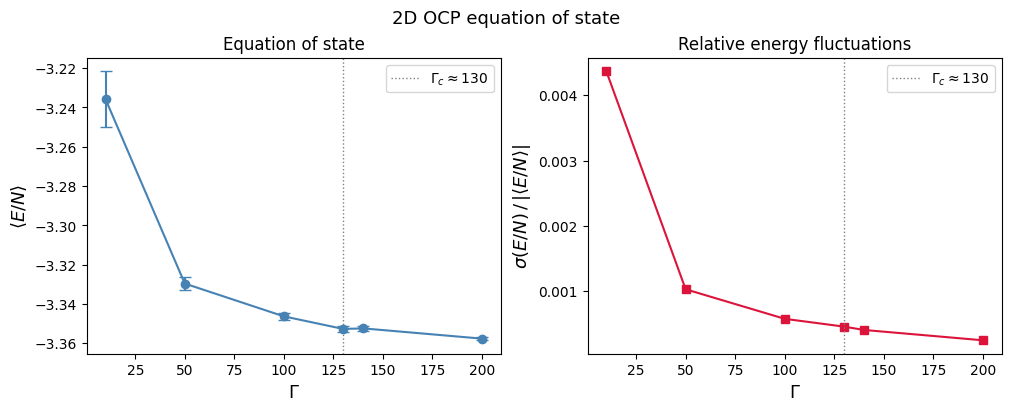

In [4]:
# ── Figure 2: mean E/N and fluctuations vs Gamma ─────────────────────────────

mean_E, std_E = [], []
for Gamma in gamma_list:
    mask = (Gammas == Gamma)
    N_part = rho[mask][0].sum()
    en = E[mask] / N_part
    mean_E.append(en.mean())
    std_E.append(en.std())

mean_E = np.array(mean_E)
std_E  = np.array(std_E)

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# panel a: E/N vs Gamma
ax1.errorbar(gamma_list, mean_E, yerr=std_E,
             fmt='o-', capsize=4, color='steelblue', lw=1.5)
ax1.axvline(130, ls=':', color='grey', lw=1, label=r"$\Gamma_c \approx 130$")
ax1.set_xlabel(r"$\Gamma$", fontsize=13)
ax1.set_ylabel(r"$\langle E/N \rangle$", fontsize=13)
ax1.set_title("Equation of state")
ax1.legend()

# panel b: relative fluctuations  sigma(E)/|mean(E)|  — proxy for heat capacity
ax2.plot(gamma_list, std_E / np.abs(mean_E),
         's-', color='crimson', lw=1.5)
ax2.axvline(130, ls=':', color='grey', lw=1, label=r"$\Gamma_c \approx 130$")
ax2.set_xlabel(r"$\Gamma$", fontsize=13)
ax2.set_ylabel(r"$\sigma(E/N) \,/\, |\langle E/N \rangle|$", fontsize=13)
ax2.set_title("Relative energy fluctuations")
ax2.legend()

fig2.suptitle("2D OCP equation of state", fontsize=13)
plt.show()

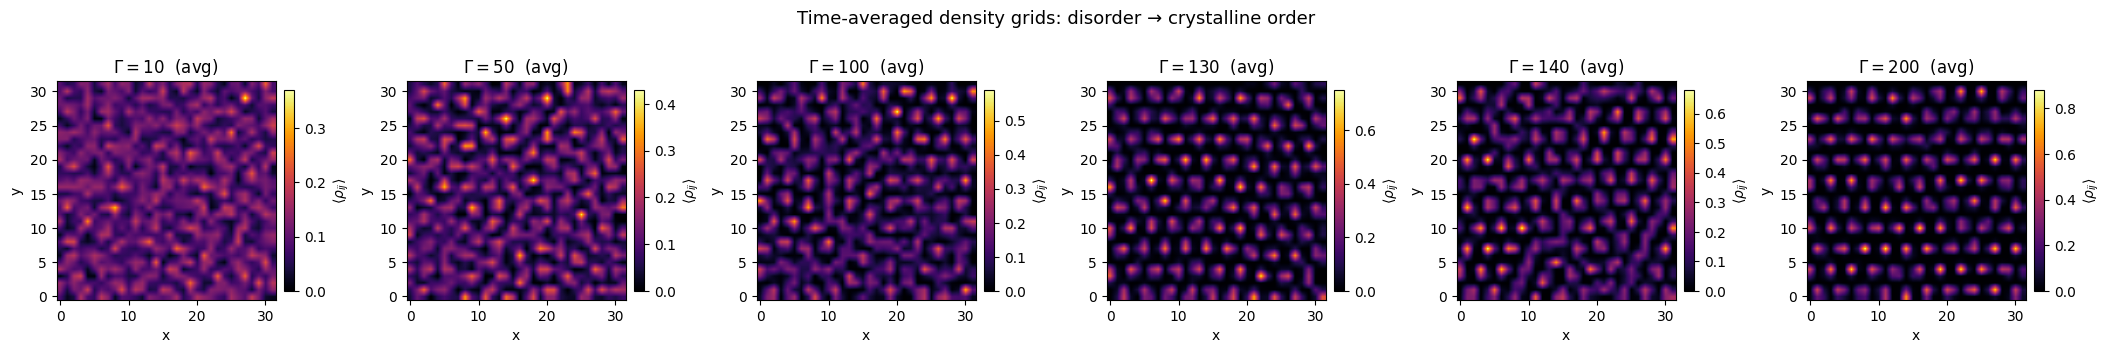

In [5]:
# ── Figure 3: average density grids — liquid vs crystal ──────────────────────

fig3, axes3 = plt.subplots(1, n_gamma, figsize=(3.5 * n_gamma, 3.5),
                            constrained_layout=True)
if n_gamma == 1:
    axes3 = [axes3]

for ax, Gamma in zip(axes3, gamma_list):
    mask     = (Gammas == Gamma)
    rho_mean = rho[mask].mean(axis=0)
    im = ax.imshow(rho_mean.T, origin='lower', cmap='inferno',
                   interpolation='bilinear')
    ax.set_title(rf"$\Gamma = {Gamma}$  (avg)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label=r"$\langle\rho_{ij}\rangle$")

fig3.suptitle("Time-averaged density grids: disorder → crystalline order",
              fontsize=13)
#fig3.savefig("ocp_avg_density.pdf", bbox_inches='tight')
#fig3.savefig("ocp_avg_density.png", dpi=150, bbox_inches='tight')
#print("Saved ocp_avg_density.pdf / .png")
plt.show()

Computing S_peak for all snapshots...
Saved ocp_order_parameter.pdf/.png


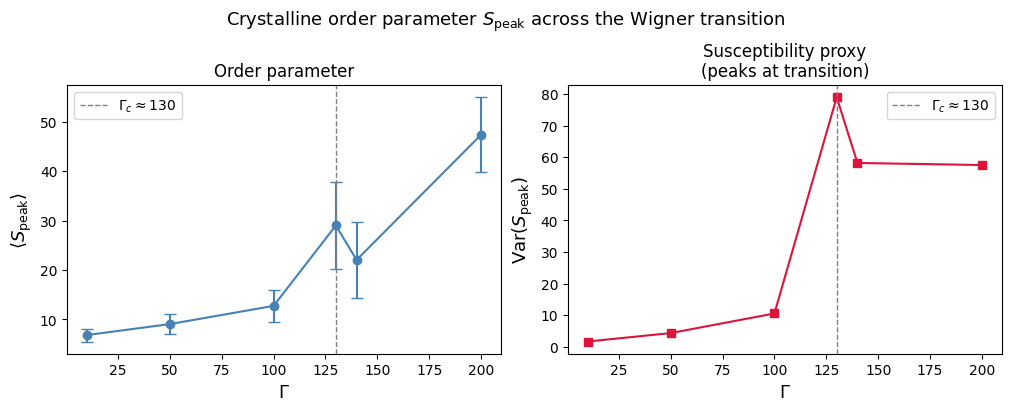

Saved ocp_speak_traces.pdf/.png


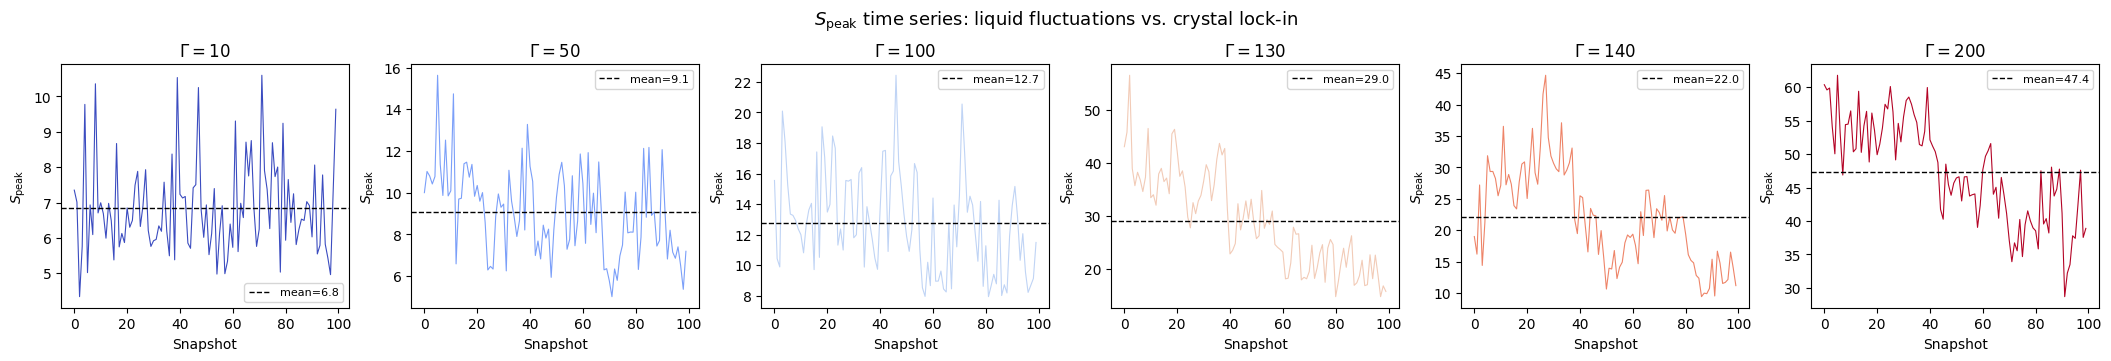

Saved ocp_Sq_avg.pdf/.png


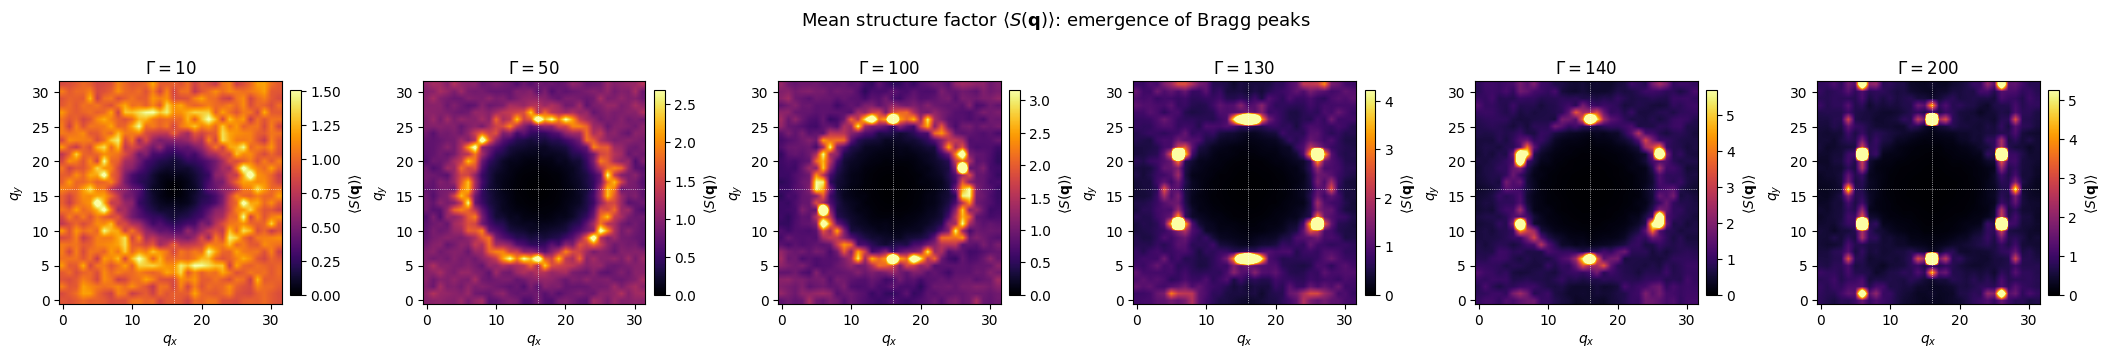

Saved ocp_varmap.pdf/.png


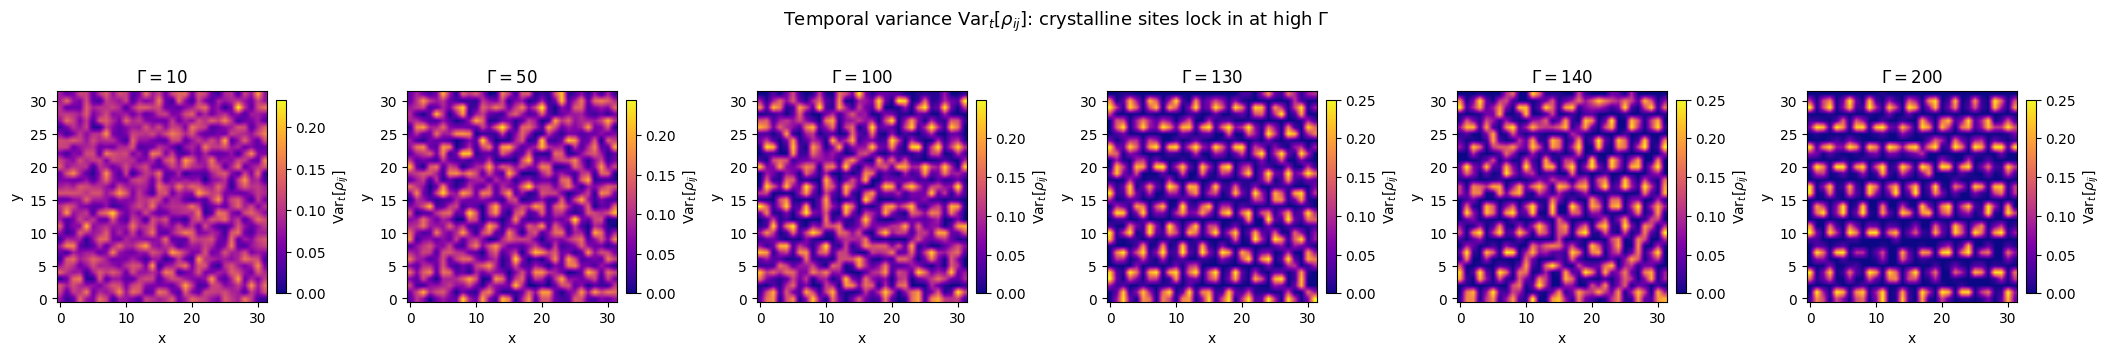

In [6]:
"""
Visualisation of density fluctuations and crystalline order across the
Wigner crystal transition in the 2D OCP.

Requires: wigner_rho.npy, wigner_E.npy, wigner_Gamma.npy

Figures produced
----------------
Fig 1  — S_peak vs Gamma: mean + variance (order parameter curve)
Fig 2  — Snapshot-to-snapshot fluctuations of S_peak at each Gamma
Fig 3  — 2D structure factor S(q) averaged over snapshots, per Gamma
Fig 4  — Spatial variance map: Var_t[rho_ij] per grid cell, per Gamma
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── load ─────────────────────────────────────────────────────────────────────

rho    = np.load("wigner_rho.npy")    # (n_total, G, G)
E      = np.load("wigner_E.npy")
Gammas = np.load("wigner_Gamma.npy")

gamma_list = sorted(set(Gammas.astype(int).tolist()))
G          = rho.shape[1]
n_gamma    = len(gamma_list)

# ── structure factor utilities ────────────────────────────────────────────────

def Sq_2d(rho_grid):
    """S(q) = |FFT(rho)|^2 / N, zero-frequency shifted."""
    N  = rho_grid.sum()
    ft = np.fft.fftshift(np.fft.fft2(rho_grid))
    Sq = np.abs(ft)**2 / max(N, 1)
    # zero out DC component to avoid trivial peak
    Sq[G//2, G//2] = 0.0
    return Sq

def speak(rho_grid):
    """Scalar order parameter: max of S(q) excluding q=0."""
    return Sq_2d(rho_grid).max()

# ── compute per-snapshot S_peak ───────────────────────────────────────────────

print("Computing S_peak for all snapshots...")
sp_all = np.array([speak(rho[i]) for i in range(len(rho))])

# ── Fig 1: S_peak mean and variance vs Gamma ─────────────────────────────────

mean_sp = []
std_sp  = []
var_sp  = []

for Gamma in gamma_list:
    mask = (Gammas == Gamma)
    sp   = sp_all[mask]
    mean_sp.append(sp.mean())
    std_sp.append(sp.std())
    var_sp.append(sp.var())

mean_sp = np.array(mean_sp)
std_sp  = np.array(std_sp)
var_sp  = np.array(var_sp)

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ax1.errorbar(gamma_list, mean_sp, yerr=std_sp,
             fmt='o-', capsize=4, color='steelblue', lw=1.5)
ax1.axvline(130, ls='--', color='grey', lw=1, label=r'$\Gamma_c \approx 130$')
ax1.set_xlabel(r'$\Gamma$', fontsize=13)
ax1.set_ylabel(r'$\langle S_{\rm peak} \rangle$', fontsize=13)
ax1.set_title('Order parameter')
ax1.legend()

ax2.plot(gamma_list, var_sp, 's-', color='crimson', lw=1.5)
ax2.axvline(130, ls='--', color='grey', lw=1, label=r'$\Gamma_c \approx 130$')
ax2.set_xlabel(r'$\Gamma$', fontsize=13)
ax2.set_ylabel(r'${\rm Var}(S_{\rm peak})$', fontsize=13)
ax2.set_title('Susceptibility proxy\n(peaks at transition)')
ax2.legend()

fig1.suptitle(r'Crystalline order parameter $S_{\rm peak}$ across the Wigner transition',
              fontsize=13)
fig1.savefig('ocp_order_parameter.pdf', bbox_inches='tight')
fig1.savefig('ocp_order_parameter.png', dpi=150, bbox_inches='tight')
print("Saved ocp_order_parameter.pdf/.png")
plt.show()

# ── Fig 2: S_peak time series per Gamma ──────────────────────────────────────

fig2, axes = plt.subplots(1, n_gamma, figsize=(3.5*n_gamma, 3.5),
                           constrained_layout=True, sharey=False)
if n_gamma == 1:
    axes = [axes]

colors = plt.cm.coolwarm(np.linspace(0, 1, n_gamma))

for ax, Gamma, col in zip(axes, gamma_list, colors):
    mask = (Gammas == Gamma)
    sp   = sp_all[mask]
    ax.plot(sp, lw=0.8, color=col)
    ax.axhline(sp.mean(), ls='--', color='k', lw=1,
               label=f'mean={sp.mean():.1f}')
    ax.set_title(rf'$\Gamma={Gamma}$')
    ax.set_xlabel('Snapshot')
    ax.set_ylabel(r'$S_{\rm peak}$')
    ax.legend(fontsize=8)

fig2.suptitle(r'$S_{\rm peak}$ time series: liquid fluctuations vs. crystal lock-in',
              fontsize=13)
fig2.savefig('ocp_speak_traces.pdf', bbox_inches='tight')
fig2.savefig('ocp_speak_traces.png', dpi=150, bbox_inches='tight')
print("Saved ocp_speak_traces.pdf/.png")
plt.show()

# ── Fig 3: mean S(q) map per Gamma ───────────────────────────────────────────

fig3, axes = plt.subplots(1, n_gamma, figsize=(3.5*n_gamma, 3.5),
                           constrained_layout=True)
if n_gamma == 1:
    axes = [axes]

for ax, Gamma in zip(axes, gamma_list):
    mask   = (Gammas == Gamma)
    Sq_avg = np.mean([Sq_2d(rho[i]) for i in np.where(mask)[0]], axis=0)
    vmax   = np.percentile(Sq_avg, 99)
    im = ax.imshow(Sq_avg.T, origin='lower', cmap='inferno',
                   vmin=0, vmax=vmax, interpolation='bilinear')
    ax.set_title(rf'$\Gamma={Gamma}$')
    ax.set_xlabel(r'$q_x$')
    ax.set_ylabel(r'$q_y$')
    # mark centre
    ax.axhline(G//2, color='w', lw=0.5, ls=':')
    ax.axvline(G//2, color='w', lw=0.5, ls=':')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label=r'$\langle S(\mathbf{q})\rangle$')

fig3.suptitle(r'Mean structure factor $\langle S(\mathbf{q})\rangle$: '
              r'emergence of Bragg peaks', fontsize=13)
fig3.savefig('ocp_Sq_avg.pdf', bbox_inches='tight')
fig3.savefig('ocp_Sq_avg.png', dpi=150, bbox_inches='tight')
print("Saved ocp_Sq_avg.pdf/.png")
plt.show()

# ── Fig 4: spatial variance map Var_t[rho_ij] ────────────────────────────────
# High variance = sites that are sometimes occupied, sometimes not.
# In the crystal phase this map reveals the lattice geometry.
# Near the transition it shows large heterogeneous fluctuations.

fig4, axes = plt.subplots(1, n_gamma, figsize=(3.5*n_gamma, 3.5),
                           constrained_layout=True)
if n_gamma == 1:
    axes = [axes]

for ax, Gamma in zip(axes, gamma_list):
    mask   = (Gammas == Gamma)
    rho_g  = rho[mask]                         # (n_snap, G, G)
    varmap = rho_g.var(axis=0)                 # (G, G)
    im = ax.imshow(varmap.T, origin='lower', cmap='plasma',
                   interpolation='bilinear')
    ax.set_title(rf'$\Gamma={Gamma}$')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label=r'${\rm Var}_t[\rho_{ij}]$')

fig4.suptitle(r'Temporal variance ${\rm Var}_t[\rho_{ij}]$: '
              r'crystalline sites lock in at high $\Gamma$', fontsize=13)
fig4.savefig('ocp_varmap.pdf', bbox_inches='tight')
fig4.savefig('ocp_varmap.png', dpi=150, bbox_inches='tight')
print("Saved ocp_varmap.pdf/.png")
plt.show()